# ДЗ 2 — траектория мяча с сопротивлением

Упрощённый вариант оформления и кода.


In [9]:
import os
import time
import math
import numpy as np

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
import matplotlib.pyplot as plt
from numba import njit

# Константы задачи
G = 9.81
V0 = 30.0
BETA = 0.12
X_GOAL = 25.0
Y_GOAL = 2.44

# Начальные приближения для двух решений
INIT_LOW = (np.deg2rad(10.0), 1.0)
INIT_HIGH = (np.deg2rad(76.0), 5.0)

EPS_LIST = [0.1, 0.01, 0.0001]
DTYPES = [np.float16, np.float32, np.float64]


In [10]:
# Модель и метод простых итераций

def coords(theta, t, v0, beta, g):
    e = np.exp(-beta * t)
    x = (v0 * np.cos(theta) / beta) * (1.0 - e)
    y = ((v0 * np.sin(theta) + g / beta) / beta) * (1.0 - e) - (g / beta) * t
    return x, y


def F(theta, t, v0, beta, g, x_goal, y_goal):
    x, y = coords(theta, t, v0, beta, g)
    return x - x_goal, y - y_goal, x, y


def jacobian(theta, t, v0, beta, g):
    e = np.exp(-beta * t)
    one_minus_e = 1.0 - e
    s = np.sin(theta)
    c = np.cos(theta)

    j11 = -(v0 * s / beta) * one_minus_e
    j12 = v0 * c * e
    j21 = (v0 * c / beta) * one_minus_e
    j22 = (v0 * s + g / beta) * e - g / beta
    return j11, j12, j21, j22


def solve_system(theta0, t0, b=0.9, eps=1e-4, dtype=np.float64, max_iter=5000):
    # Переводим всё в выбранный формат
    v0 = dtype(V0)
    beta = dtype(BETA)
    g = dtype(G)
    x_goal = dtype(X_GOAL)
    y_goal = dtype(Y_GOAL)

    theta = dtype(theta0)
    t = dtype(t0)
    b = dtype(b)

    # Фиксируем матрицу A = J(z0)^(-1)
    j11, j12, j21, j22 = jacobian(theta, t, v0, beta, g)
    det = j11 * j22 - j12 * j21
    if abs(float(det)) < 1e-12:
        det = dtype(1e-12)
    inv_det = dtype(1.0) / det

    a11 = j22 * inv_det
    a12 = -j12 * inv_det
    a21 = -j21 * inv_det
    a22 = j11 * inv_det

    t0_clock = time.perf_counter()
    converged = False

    for it in range(1, max_iter + 1):
        f1, f2, x, y = F(theta, t, v0, beta, g, x_goal, y_goal)
        if max(abs(float(f1)), abs(float(f2))) <= eps:
            converged = True
            break

        dtheta = a11 * f1 + a12 * f2
        dt = a21 * f1 + a22 * f2

        theta = theta - b * dtheta
        t = t - b * dt

        # Простые ограничения на область
        if float(t) <= 1e-6:
            t = dtype(1e-6)
        if float(theta) <= 1e-6:
            theta = dtype(1e-6)
        upper = dtype(np.pi / 2 - 1e-6)
        if float(theta) >= float(upper):
            theta = upper

    elapsed_ms = (time.perf_counter() - t0_clock) * 1000.0
    f1, f2, x, y = F(theta, t, v0, beta, g, x_goal, y_goal)

    return {
        'ok': converged,
        'it': it,
        'theta': float(theta),
        't': float(t),
        'x': float(x),
        'y': float(y),
        'res': max(abs(float(f1)), abs(float(f2))),
        'time_ms': elapsed_ms,
    }


## 1) Графически находим области корней


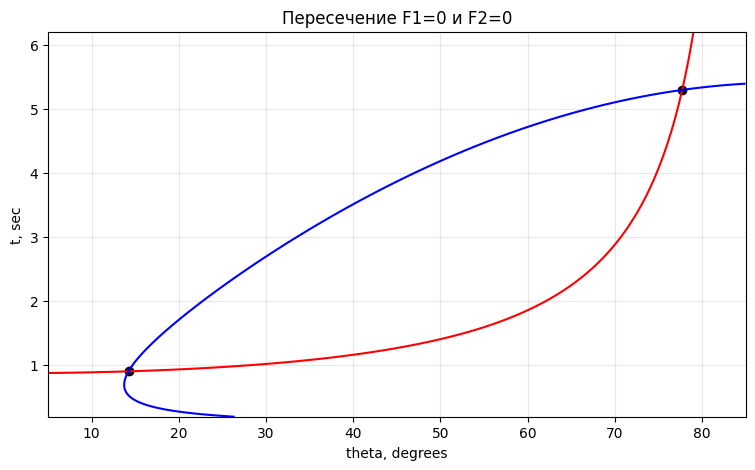

Примерные области корней:
низкая: theta ≈ 14.2202°, t ≈ 0.9073
навесная: theta ≈ 77.7190°, t ≈ 5.2927


In [11]:
theta_deg = np.linspace(5, 85, 300)
t_vals = np.linspace(0.2, 6.2, 300)
TH_deg, TT = np.meshgrid(theta_deg, t_vals)
TH = np.deg2rad(TH_deg)

E = np.exp(-BETA * TT)
X = (V0 * np.cos(TH) / BETA) * (1.0 - E)
Y = ((V0 * np.sin(TH) + G / BETA) / BETA) * (1.0 - E) - (G / BETA) * TT

F1 = X - X_GOAL
F2 = Y - Y_GOAL

# Точные точки для отметки
ref_low = solve_system(INIT_LOW[0], INIT_LOW[1], b=0.9, eps=1e-12, dtype=np.float64)
ref_high = solve_system(INIT_HIGH[0], INIT_HIGH[1], b=0.9, eps=1e-12, dtype=np.float64)

plt.figure(figsize=(9, 5))
plt.contour(TH_deg, TT, F1, levels=[0.0], colors=['red'])
plt.contour(TH_deg, TT, F2, levels=[0.0], colors=['blue'])
plt.scatter([
    np.rad2deg(ref_low['theta']),
    np.rad2deg(ref_high['theta'])
], [ref_low['t'], ref_high['t']], color='black')
plt.xlabel('theta, degrees')
plt.ylabel('t, sec')
plt.title('Пересечение F1=0 и F2=0')
plt.grid(alpha=0.3)
plt.show()

print('Примерные области корней:')
print(f"низкая: theta ≈ {np.rad2deg(ref_low['theta']):.4f}°, t ≈ {ref_low['t']:.4f}")
print(f"навесная: theta ≈ {np.rad2deg(ref_high['theta']):.4f}°, t ≈ {ref_high['t']:.4f}")


## 2) Подбираем параметр b (0.1 ... 0.9)


In [12]:
b_values = np.round(np.arange(0.1, 1.0, 0.1), 1)
scan = []

print('b     it_low  it_high  avg_it')
for b in b_values:
    r_low = solve_system(INIT_LOW[0], INIT_LOW[1], b=float(b), eps=1e-4, dtype=np.float64)
    r_high = solve_system(INIT_HIGH[0], INIT_HIGH[1], b=float(b), eps=1e-4, dtype=np.float64)
    avg_it = 0.5 * (r_low['it'] + r_high['it'])
    scan.append((float(b), r_low['it'], r_high['it'], avg_it))
    print(f"{b:<4.1f}  {r_low['it']:<6d}  {r_high['it']:<7d}  {avg_it:.1f}")

B_OPT = min(scan, key=lambda x: x[3])[0]
print()
print(f"Выбрали b = {B_OPT:.1f}")


b     it_low  it_high  avg_it
0.1   110     95       102.5
0.2   53      45       49.0
0.3   34      29       31.5
0.4   24      20       22.0
0.5   18      15       16.5
0.6   14      12       13.0
0.7   12      9        10.5
0.8   9       7        8.0
0.9   7       5        6.0

Выбрали b = 0.9


## 3) Строим две траектории


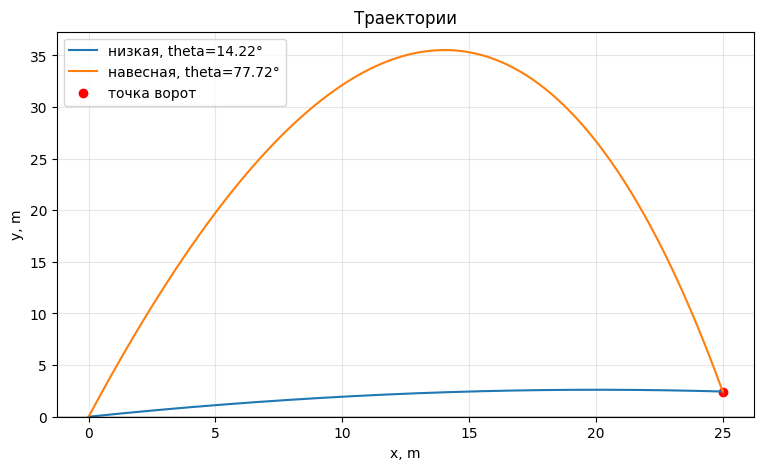

Решения:
низкая: theta=14.220152°, t=0.907324, x=25.000000, y=2.440000
навесная: theta=77.719033°, t=5.292742, x=25.000000, y=2.440000


In [13]:
ref_low = solve_system(INIT_LOW[0], INIT_LOW[1], b=B_OPT, eps=1e-12, dtype=np.float64)
ref_high = solve_system(INIT_HIGH[0], INIT_HIGH[1], b=B_OPT, eps=1e-12, dtype=np.float64)


def trajectory(theta, t_hit, n=300):
    t_grid = np.linspace(0, t_hit, n)
    x, y = coords(theta, t_grid, V0, BETA, G)
    return x, y

x1, y1 = trajectory(ref_low['theta'], ref_low['t'])
x2, y2 = trajectory(ref_high['theta'], ref_high['t'])

plt.figure(figsize=(9, 5))
plt.plot(x1, y1, label=f"низкая, theta={np.rad2deg(ref_low['theta']):.2f}°")
plt.plot(x2, y2, label=f"навесная, theta={np.rad2deg(ref_high['theta']):.2f}°")
plt.scatter([X_GOAL], [Y_GOAL], color='red', label='точка ворот')
plt.axhline(0, color='black', lw=1)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.title('Траектории')
plt.xlabel('x, m')
plt.ylabel('y, m')
plt.show()

print('Решения:')
print(f"низкая: theta={np.rad2deg(ref_low['theta']):.6f}°, t={ref_low['t']:.6f}, x={ref_low['x']:.6f}, y={ref_low['y']:.6f}")
print(f"навесная: theta={np.rad2deg(ref_high['theta']):.6f}°, t={ref_high['t']:.6f}, x={ref_high['x']:.6f}, y={ref_high['y']:.6f}")


## 4) Эксперименты: float16/float32/float64 и eps

Считаем абсолютную ошибку относительно эталона `float64, eps=1e-12`.


In [14]:
results = []

for traj_name, init, ref in [
    ('low', INIT_LOW, ref_low),
    ('high', INIT_HIGH, ref_high),
]:
    for dtype in DTYPES:
        for eps in EPS_LIST:
            r = solve_system(init[0], init[1], b=B_OPT, eps=eps, dtype=dtype)
            abs_err = max(
                abs(r['theta'] - ref['theta']),
                abs(r['t'] - ref['t']),
                abs(r['x'] - ref['x']),
                abs(r['y'] - ref['y']),
            )
            results.append({
                'traj': traj_name,
                'dtype': dtype.__name__,
                'eps': eps,
                'ok': r['ok'],
                'theta_deg': np.rad2deg(r['theta']),
                't': r['t'],
                'x': r['x'],
                'y': r['y'],
                'it': r['it'],
                'time_ms': r['time_ms'],
                'abs_err': abs_err,
            })

print('traj  dtype    eps      ok   it    time_ms   theta_deg   t        x        y        abs_err')
for row in results:
    print(
        f"{row['traj']:<5} {row['dtype']:<8} {row['eps']:<8g} {str(row['ok']):<4} "
        f"{row['it']:<5d} {row['time_ms']:<9.4f} {row['theta_deg']:<10.6f} "
        f"{row['t']:<8.5f} {row['x']:<8.5f} {row['y']:<8.5f} {row['abs_err']:.3e}"
    )


traj  dtype    eps      ok   it    time_ms   theta_deg   t        x        y        abs_err
low   float16  0.1      True 4     0.0238    14.316951  0.90723  24.95312 2.43750  4.688e-02
low   float16  0.01     False 5000  23.5963   14.086145  0.90576  24.98438 2.37500  6.500e-02
low   float16  0.0001   False 5000  20.9822   14.086145  0.90576  24.98438 2.37500  6.500e-02
low   float32  0.1      True 3     0.0147    14.015557  0.90690  25.01136 2.35146  8.854e-02
low   float32  0.01     True 5     0.0200    14.213618  0.90725  24.99889 2.43731  2.691e-03
low   float32  0.0001   True 7     0.0276    14.220146  0.90732  24.99996 2.43999  3.815e-05
low   float64  0.1      True 3     0.0120    14.015480  0.90690  25.01137 2.35147  8.853e-02
low   float64  0.01     True 5     0.0186    14.213632  0.90725  24.99888 2.43728  2.716e-03
low   float64  0.0001   True 7     0.0257    14.220033  0.90732  24.99995 2.43995  4.784e-05
high  float16  0.1      True 3     0.0124    77.718592  5.28125  24.9

## 5) Узкое место и оптимизация numba

Узкое место: цикл итераций (много раз считаются exp/sin/cos).


In [15]:
def solve_py64(theta0, t0, b=0.9, eps=1e-4, max_iter=5000):
    r = solve_system(theta0, t0, b=b, eps=eps, dtype=np.float64, max_iter=max_iter)
    return r['ok'], r['it'], r['theta'], r['t'], r['x'], r['y'], r['res']


@njit
def solve_numba64(theta0, t0, b=0.9, eps=1e-4, max_iter=5000):
    theta = theta0
    t = t0

    # A = J(z0)^(-1)
    e = np.exp(-BETA * t)
    one_minus_e = 1.0 - e
    s = np.sin(theta)
    c = np.cos(theta)

    j11 = -(V0 * s / BETA) * one_minus_e
    j12 = V0 * c * e
    j21 = (V0 * c / BETA) * one_minus_e
    j22 = (V0 * s + G / BETA) * e - G / BETA

    det = j11 * j22 - j12 * j21
    if abs(det) < 1e-12:
        det = 1e-12
    inv_det = 1.0 / det

    a11 = j22 * inv_det
    a12 = -j12 * inv_det
    a21 = -j21 * inv_det
    a22 = j11 * inv_det

    converged = False
    it = 0

    for k in range(max_iter):
        it = k + 1
        e = np.exp(-BETA * t)
        x = (V0 * np.cos(theta) / BETA) * (1.0 - e)
        y = ((V0 * np.sin(theta) + G / BETA) / BETA) * (1.0 - e) - (G / BETA) * t
        f1 = x - X_GOAL
        f2 = y - Y_GOAL

        if max(abs(f1), abs(f2)) <= eps:
            converged = True
            break

        dtheta = a11 * f1 + a12 * f2
        dt = a21 * f1 + a22 * f2

        theta = theta - b * dtheta
        t = t - b * dt

        if t <= 1e-6:
            t = 1e-6
        if theta <= 1e-6:
            theta = 1e-6
        up = np.pi / 2 - 1e-6
        if theta >= up:
            theta = up

    e = np.exp(-BETA * t)
    x = (V0 * np.cos(theta) / BETA) * (1.0 - e)
    y = ((V0 * np.sin(theta) + G / BETA) / BETA) * (1.0 - e) - (G / BETA) * t
    res = max(abs(x - X_GOAL), abs(y - Y_GOAL))

    return converged, it, theta, t, x, y, res


# Прогрев JIT
_ = solve_numba64(float(INIT_LOW[0]), float(INIT_LOW[1]), b=B_OPT, eps=1e-4, max_iter=5000)

N = 20000
for name, init in [('low', INIT_LOW), ('high', INIT_HIGH)]:
    th0, t0 = float(init[0]), float(init[1])

    t_start = time.perf_counter()
    for _ in range(N):
        py = solve_py64(th0, t0, b=B_OPT, eps=1e-4)
    py_ms = (time.perf_counter() - t_start) * 1000

    t_start = time.perf_counter()
    for _ in range(N):
        nb = solve_numba64(th0, t0, b=B_OPT, eps=1e-4)
    nb_ms = (time.perf_counter() - t_start) * 1000

    print(f"{name}: python={py_ms:.2f} ms, numba={nb_ms:.2f} ms, speedup={py_ms/nb_ms:.2f}x")


low: python=695.92 ms, numba=178.94 ms, speedup=3.89x
high: python=537.61 ms, numba=15.14 ms, speedup=35.51x


## 6) Короткий отчёт по результатам

- На графике видно 2 решения: низкая и навесная траектория.
- Подбор `b` в диапазоне `0.1..0.9` показывает, что большое `b` даёт меньше итераций.
- `float64` и `float32` дают близкие результаты; `float16` заметно грубее и может не сходиться на строгом `eps`.
- Узкое место — итерационный цикл; `numba` заметно ускоряет серию запусков.
- Для практики: использовать `float32/float64`, а при массовых расчётах включать `numba`.
